In [16]:
import dynesty 
import matplotlib.pyplot as plt
import os 
import sys
import pickle
import numpy as np

In [8]:
# Changing working directory
# for VSC
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

In [9]:
with open('ns_intrinsic.pkl', 'rb') as f:
    dres = pickle.load(f) # deserialize using load()

In [10]:
dres.summary()

Summary
niter: 18207
ncall: 343904
eff(%):  4.378
logz: -15.467 +/-  0.099


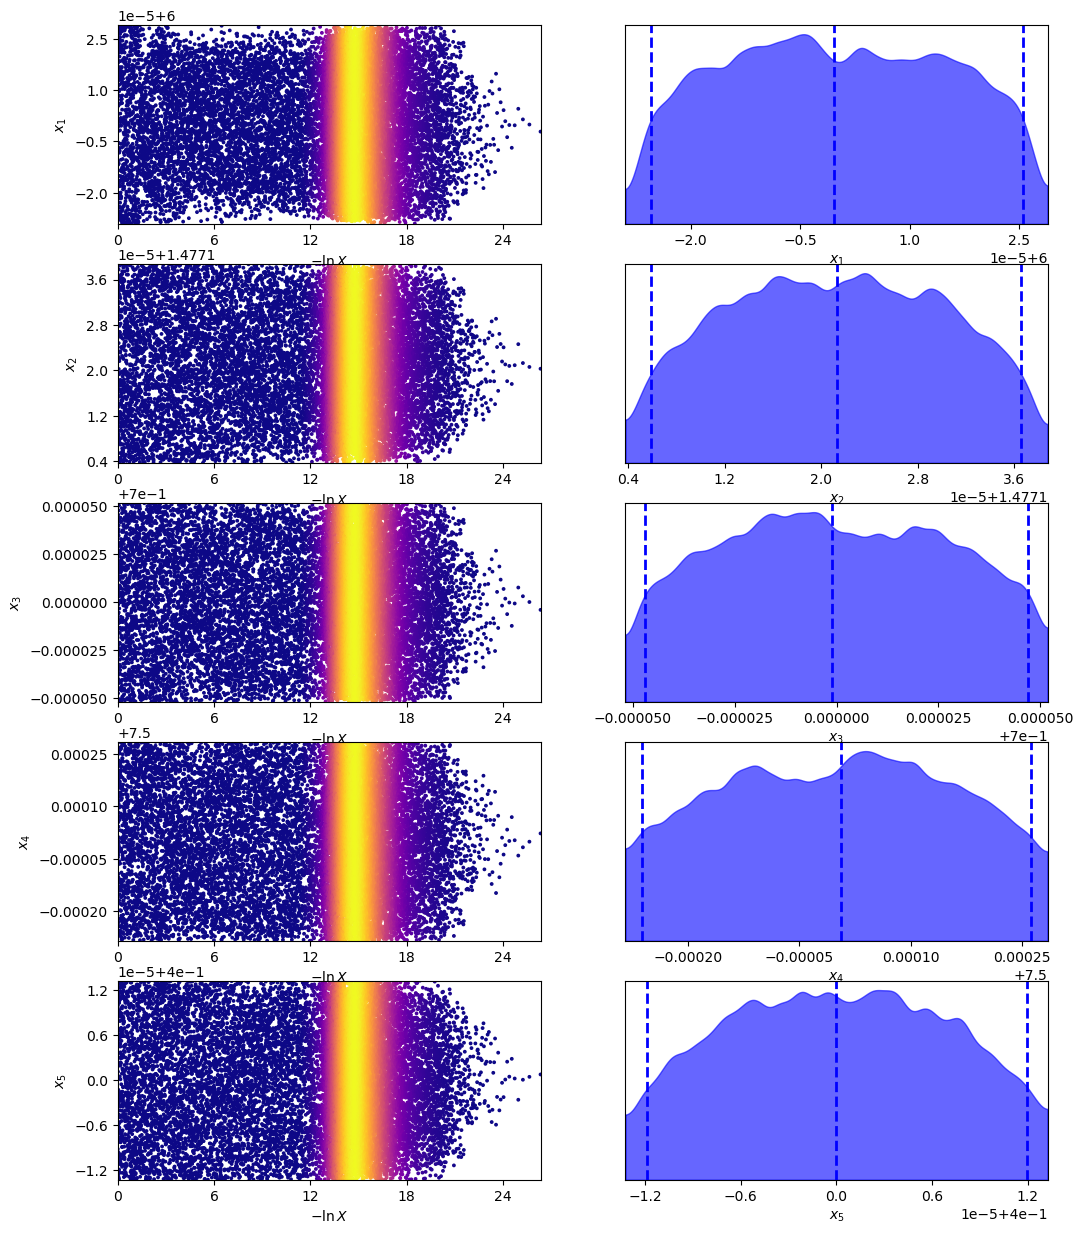

In [11]:
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
fig, axes = dyplot.traceplot(dres)
plt.show()

In [12]:
from dynesty import utils as dyfunc

samples, weights = dres.samples, dres.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
ndim = len(mean)
imp_weights = dres.importance_weights()

In [13]:
labels = ['logm1', 'logm2', 'a', 'p0', 'e0']

In [17]:
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

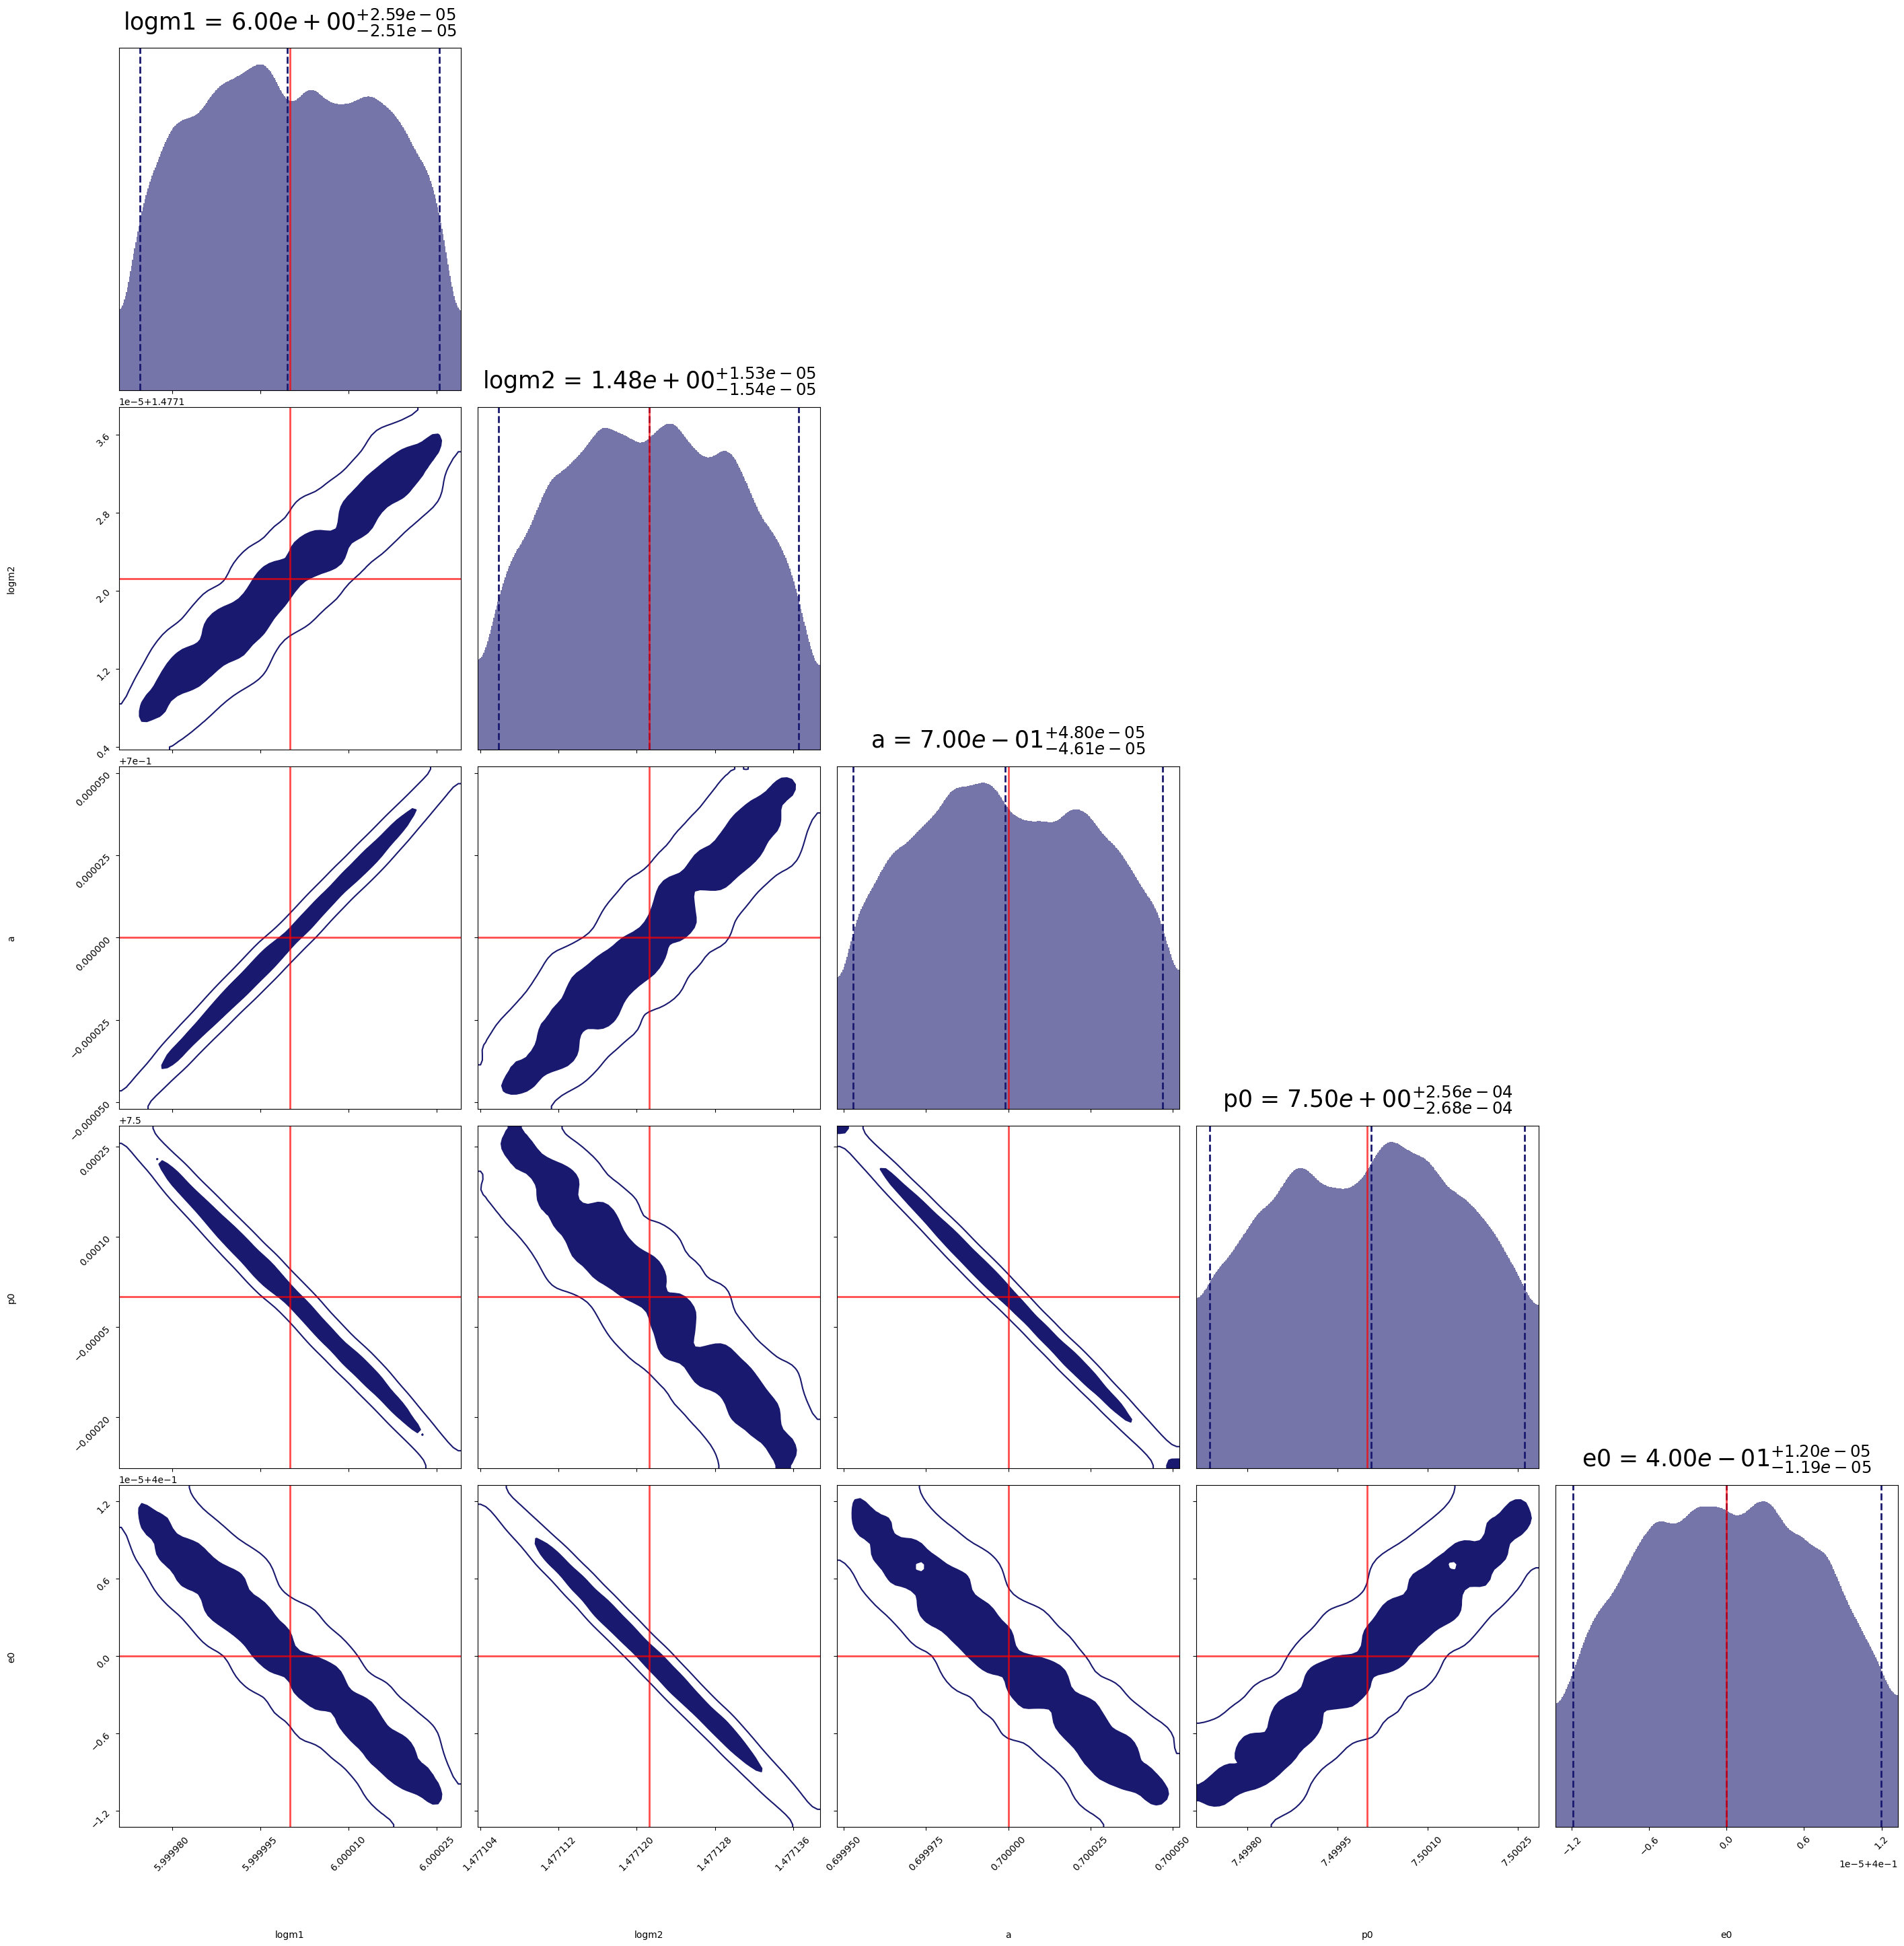

In [29]:
#cornerplot
from dynesty import plotting as dyplot
import matplotlib.pyplot as plt
fig, axes = dyplot.cornerplot(dres, show_titles=True, truth_color='red', smooth=0.03, color='midnightblue', quantiles_2d = [0.4, 0.85],
                              title_kwargs={'y': 1.04,'fontsize':25}, title_fmt='.2e',
                              fig=plt.subplots(ndim, ndim, figsize=(30, 30)), labels=labels, 
                              truths= [np.log10(m1), np.log10(m2), a, p0, e0], span = [(5.9999709082e+00, 6.0000290918e+00),
                                                                                       (1.4771037246e+00, 1.4771387849e+00),
                                                                                       (6.9994800136e-01, 7.0005199864e-01),
                                                                                       (7.4997151844e+00, 7.5002848156e+00),
                                                                                       (3.9998674362e-01, 4.0001325638e-01)])

In [30]:
# Changing working directory
# for VSC
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test/')

In [31]:
with open('cov_matrix_intrinsic.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

In [32]:
cov_matrix

array([[ 8.46332187e-12,  5.06119872e-12,  1.51204038e-11,
        -8.28090567e-11, -3.81668865e-12],
       [ 5.06119872e-12,  3.07305987e-12,  9.01008955e-12,
        -4.93120462e-11, -2.32279066e-12],
       [ 1.51204038e-11,  9.01008955e-12,  2.70385828e-11,
        -1.48095639e-10, -6.78955885e-12],
       [-8.28090567e-11, -4.93120462e-11, -1.48095639e-10,
         8.11199431e-10,  3.71586395e-11],
       [-3.81668865e-12, -2.32279066e-12, -6.78955885e-12,
         3.71586395e-11,  1.75731597e-12]])